## Pasha Mulenga
### Maternal health analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report

plt.style.use("ggplot")

DATA_PATH = "Maternal Health Risk Data Set.csv"

## 2. Data Acquisition

In [7]:
df = pd.read_csv(DATA_PATH)

df.head()

df.info()

df.describe()

df.isnull().sum()

df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          1014 non-null   int64  
 1   SystolicBP   1014 non-null   int64  
 2   DiastolicBP  1014 non-null   int64  
 3   BS           1014 non-null   float64
 4   BodyTemp     1014 non-null   float64
 5   HeartRate    1014 non-null   int64  
 6   RiskLevel    1014 non-null   object 
dtypes: float64(2), int64(4), object(1)
memory usage: 55.6+ KB


562

## 3. Sql Database Layer

In [ ]:
## Query 1: Average vital signs by risk level
query1 = """
SELECT
RiskLevel,
AVG(SystolicBP) as avg_systolic,
AVG(DiastolicBP) as avg_diastolic,
AVG(HeartRate) as avg_hr
FROM maternal_health
GROUP BY RiskLevel
"""

pd.read_sql(query1, conn)

In [ ]:
## Query 2: Average vital signs by risk level
query2 = """
SELECT COUNT(*) as high_bs_cases
FROM maternal_health
WHERE BS > 8
"""

pd.read_sql(query2, conn)

In [ ]:
## Query 3: High risk patients above age 35
query3 = """
SELECT COUNT(*) as high_risk_age35
FROM maternal_health
WHERE Age > 35 AND RiskLevel = 'high risk'
"""

pd.read_sql(query3, conn)

In [ ]:
## Query 4: Fever cases
query4 = """
SELECT RiskLevel, COUNT(*) as fever_cases
FROM maternal_health
WHERE BodyTemp > 99
GROUP BY RiskLevel
"""

pd.read_sql(query4, conn)

## 4. Exploratory analysis

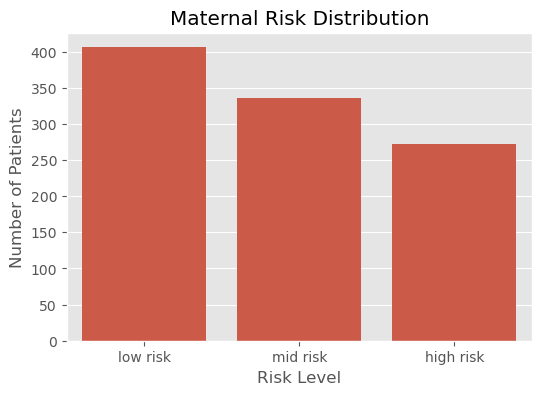

In [11]:
## Risk distribution
risk_counts = df['RiskLevel'].value_counts()

plt.figure(figsize=(6,4))
sns.barplot(x=risk_counts.index, y=risk_counts.values)

plt.title("Maternal Risk Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of Patients")

plt.show()

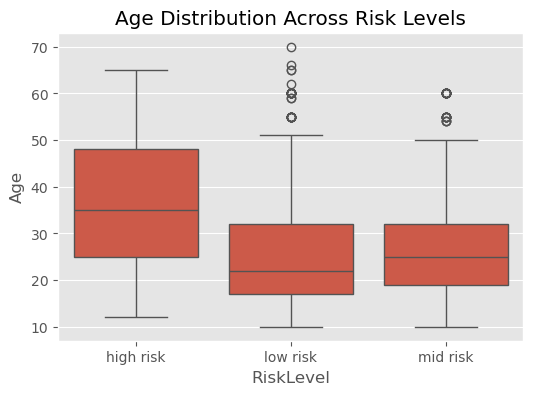

In [13]:
## Age vs risk level
plt.figure(figsize=(6,4))

sns.boxplot(
data=df,
x="RiskLevel",
y="Age"
)

plt.title("Age Distribution Across Risk Levels")

plt.show()

## 5. Clinical Correlation Analysis

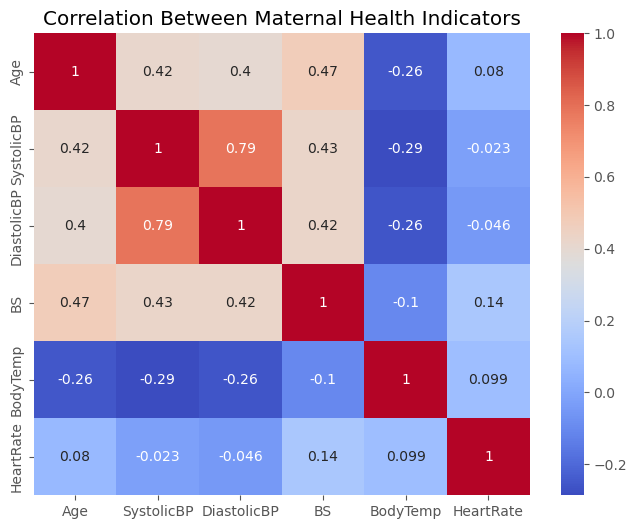

In [15]:
## Correlation Matrix
corr = df.drop(columns=["RiskLevel"]).corr()

plt.figure(figsize=(8,6))

sns.heatmap(
corr,
annot=True,
cmap="coolwarm"
)

plt.title("Correlation Between Maternal Health Indicators")

plt.show()

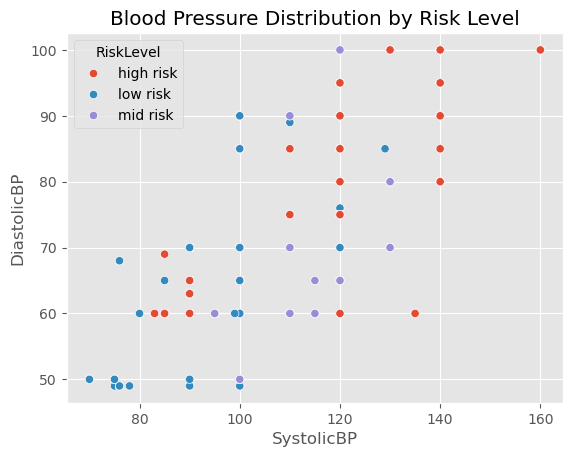

In [17]:
## Blood pressure distributions
sns.scatterplot(
data=df,
x="SystolicBP",
y="DiastolicBP",
hue="RiskLevel"
)

plt.title("Blood Pressure Distribution by Risk Level")

plt.show()

## 6. Risk Fcator modeling

In [19]:
## Encode risk labels
encoder = LabelEncoder()

df["RiskEncoded"] = encoder.fit_transform(df["RiskLevel"])

In [21]:
## Split dataset
X = df.drop(columns=["RiskLevel","RiskEncoded"])
y = df["RiskEncoded"]

X_train, X_test, y_train, y_test = train_test_split(
X,
y,
test_size=0.2,
random_state=42
)

In [23]:
## Train Model
model = RandomForestClassifier(n_estimators=200)

model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200)

In [25]:
## Evaluate model
predictions = model.predict(X_test)

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.87      0.85      0.86        47
           1       0.89      0.78      0.83        80
           2       0.76      0.87      0.81        76

    accuracy                           0.83       203
   macro avg       0.84      0.83      0.83       203
weighted avg       0.83      0.83      0.83       203



## 7. Risk Matrics

In [27]:
## Created a martenal risk score
df["RiskScore"] = (
0.25 * df["SystolicBP"] +
0.20 * df["DiastolicBP"] +
0.25 * df["BS"] +
0.15 * df["HeartRate"] +
0.15 * df["BodyTemp"]
)

In [29]:
## Evaluation of average risk level
df.groupby("RiskLevel")["RiskScore"].mean()

RiskLevel
high risk    77.440358
low risk     68.449698
mid risk     71.035394
Name: RiskScore, dtype: float64

## 8. Patient profile segmentation

In [31]:
## Cluster maternal health profiles
features = df.drop(columns=["RiskLevel","RiskEncoded"])

kmeans = KMeans(n_clusters=3, random_state=42)

df["Cluster"] = kmeans.fit_predict(features)

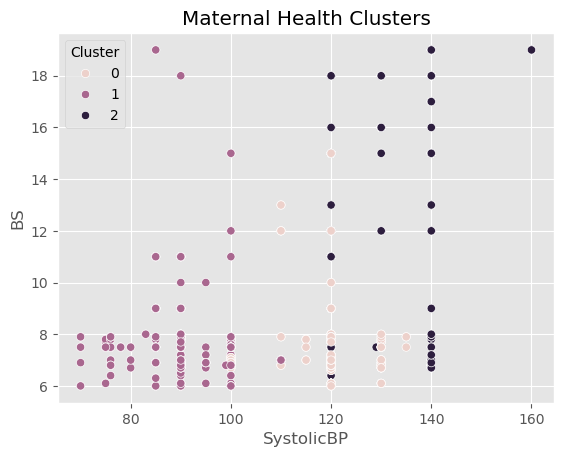

In [33]:
## Cluster Visulization
sns.scatterplot(
data=df,
x="SystolicBP",
y="BS",
hue="Cluster"
)

plt.title("Maternal Health Clusters")

plt.show()